# Importing packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 10, "figure.autolayout": True})

# Ingesting data

In [2]:
df1 = pd.read_csv(r"C:\Users\this pc\Dropbox\PC\Documents\Personal projects\Credit risk dataset\dataset.csv")

# Looking at the top 5 rows of the data
df1.head(5)

,id,Duration in months,Credit history,Purpose of the credit,Credit amount,Status of savings account/bonds,Present employment(years),Installment rate in percentage of disposable income,personal_status,Other debtors / guarantors,...,Property,Age in years,Other installment plans (banks/stores),Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker,Status of existing checking account
0,1,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,2,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,3,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,4,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,5,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [3]:
# Making the copy of the original data
df = df1.copy()

# Exploratory data analysis (EDA)

In [4]:
# Checking the information about the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                                                    Non-Null Count  Dtype
---  ------                                                    --------------  -----
 0   id                                                        1000 non-null   int64
 1   Duration in months                                        1000 non-null   int64
 2   Credit history                                            1000 non-null   str  
 3   Purpose of the credit                                     1000 non-null   str  
 4   Credit amount                                             1000 non-null   int64
 5   Status of savings account/bonds                           1000 non-null   str  
 6   Present employment(years)                                 1000 non-null   str  
 7   Installment rate in percentage of disposable income       1000 non-null   int64
 8   personal_status                                   

# Observations:
- Dataset Dimensions: The dataset consists of 1,000 entries (rows) and 21 columns (indexed 0 to 20).
- Missing Values: There are no missing values across any of the columns (all columns show 1000 non-null).

## Data Types:
- There are 8 Numerical Columns (int64): id, Duration in months, Credit amount, Installment rate in percentage of disposable income, Present residence since X years, Age in years, Number of existing credits at this bank, and Number of people being liable to provide maintenance for.
- There are 13 Categorical Columns (str): Credit history, Purpose of the credit, Status of savings account/bonds, Present employment(years), personal_status, Other debtors / guarantors, Property, Other installment plans (banks/stores), Housing, Job, Telephone, Foreign worker, and Status of existing checking account.

In [5]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

# Observations:
- There are no identical duplicate records across all columns in the dataset.
- Every row represents a unique sample, meaning no row deletion or deduplication preprocessing is required.

In [6]:
# Checking the statistical summary of the data
df.describe()

,id,Duration in months,Credit amount,Installment rate in percentage of disposable income,Present residence since X years,Age in years,Number of existing credits at this bank,Number of people being liable to provide maintenance for
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,288.819436,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,1.000000,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,250.750000,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,500.500000,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,750.250000,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,1000.000000,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


# Observations:
- Loan Duration (Duration in months): Applicants request loan tenures ranging from 4 to 72 months, with an average duration of 20.9 months and a median of 18 months. The distribution shows a right-skew due to maximum tenures reaching 6 years.
- Credit Exposure (Credit amount): Loan requested amounts show high variance (std: 2,822.74), spanning from a minimum of 250 up to a maximum of 18,424. The mean (3,271.26) is visibly higher than the median (2,319.50), confirming significant right skewness and high-value loan outliers.
- Age Metrics (Age in years): The applicant pool ranges from young adults (19 years) to seniors (75 years), with an average age of 35.5 years and a median age of 33 years.

## Financial Commitments:
- Installment rate in percentage of disposable income centers around 3% to 4% (mean: 2.97), with 50% of applicants paying between 2% and 4%.
- Number of existing credits at this bank ranges between 1 and 4, with the vast majority of applicants holding 1 active credit account (median: 1.0, 75th percentile: 2.0).
- Number of people being liable to provide maintenance for is predominantly 1 dependent (median: 1.0, 75th percentile: 1.0), peaking at a maximum of 2 dependents.
- Residence Stability (Present residence since X years): Applicants have lived in their current residence for an average of 2.85 years (ranging from 1 to 4 years).
- Identifier Column (id): Ranges uniformly from 1 to 1,000, confirming it is simply an index column with no predictive value.

In [7]:
# Checking the number of unique values in each column
print(df['Installment rate in percentage of disposable income'].nunique())
print(df['Present residence since X years'].nunique())
print(df['Number of existing credits at this bank'].nunique())
print(df['Number of people being liable to provide maintenance for'].nunique())



4
4
4
2


# Observations:
- Installment rate in percentage of disposable income contains 4 unique values (representing discrete percentage tiers: 1, 2, 3, 4).
- Present residence since X years contains 4 unique values (representing discrete tenure brackets: 1, 2, 3, 4).
- Number of existing credits at this bank contains 4 unique values (representing discrete loan counts: 1, 2, 3, 4).
- Number of people being liable to provide maintenance for contains only 2 unique values (representing a binary split of dependent counts: 1 or 2).

In [8]:
# Checking the value counts for the 'Credit history' column
df["Credit history"].value_counts()

Credit history
existing paid                     530
critical/other existing credit    293
delayed previously                 88
all paid                           49
no credits/all paid                40
Name: count, dtype: int64

# Observaions:
- Dominant Risk Category: Over half of the applicants (530 or 53%) fall under the existing paid category, representing the primary credit history profile in this dataset.
- Critical / High-Risk Accounts: A substantial proportion (293 or 29.3%) are classified as critical/other existing credit, making it the second most frequent category.

## Minority Categories:
- delayed previously: Accounts for 88 applicants (8.8%), indicating a history of past repayment delays.
- all paid: Accounts for 49 applicants (4.9%), representing borrowers who have paid off all previous credits at this bank.
- no credits/all paid: Accounts for the smallest segment with 40 applicants (4.0%), indicating applicants with no prior credit history or all credits paid elsewhere.

In [9]:
# Checking the value counts for the 'Purpose of the credit' column
df["Purpose of the credit"].value_counts()

Purpose of the credit
radio/tv               280
new car                234
furniture/equipment    181
used car               103
business                97
education               50
repairs                 22
domestic appliance      12
other                   12
retraining               9
Name: count, dtype: int64

# Observations:
- Top Credit Driving Purposes: Consumer electronics (radio/tv) is the single most common loan purpose, accounting for 280 applications (28% of the dataset).
- Automotive Financing Segment: Vehicle purchases collectively represent 337 applications (33.7%), split between new car (234 or 23.4%) and used car (103 or 10.3%).

## Home & Business Investments:
- furniture/equipment forms the third largest individual category with 181 applications (18.1%).
- Commercial/entrepreneurial funding (business) represents 97 applications (9.7%).

## Low-Frequency / Niche Segments:
- The remaining loan categories constitute small fractions of overall volume, including education (50), repairs (22), domestic appliance (12), other (12), and retraining (9).

In [10]:
# Checking the value counts for the 'Status of savings account/bonds' column
df["Status of savings account/bonds"].value_counts()

Status of savings account/bonds
<100                603
no known savings    183
100<=X<500          103
500<=X<1000          63
>=1000               48
Name: count, dtype: int64

# Observations:
- Dominance of Low Savings: The majority of applicants (603 or 60.3%) hold less than €100  in savings (<100), indicating a heavy skew toward low liquidity borrowers.  
- Missing or Unknown Savings Data: The second largest category is no known savings with 183 applicants (18.3%), which represents unrecorded financial records or applicants without existing savings accounts.  

## Moderate to High Savings Segments: 
- 100<=X<500: Accounts for 103 applicants (10.3%).  
500<=X<1000: Accounts for 63 applicants (6.3%).  
- (>=1000): Represents the smallest group with 48 applicants (4.8%), comprising the highest liquidity applicants. 

In [11]:
# Checking the value counts for the 'Present employment(years)' column
df["Present employment(years)"].value_counts()

Present employment(years)
1<=X<4        339
>=7           253
4<=X<7        174
<1            172
unemployed     62
Name: count, dtype: int64

# Observations:
- Dominant Tenure Bracket: The largest group of applicants (339 or 33.9%) has been employed at their current job between 1 and 4 years (1<=X<4).
- High Career Stability: Over a quarter of the applicant pool (253 or 25.3%) demonstrates high employment stability, having spent 7 or more years with their current employer (>=7).

## Mid-Tier & Entry-Level Employment:
- 4<=X<7: Represents 174 applicants (17.4%).
- <1: Represents 172 applicants (17.2%), reflecting short employment duration or recent job changes.
- Unemployed Segment: The smallest category consists of 62 applicants (6.2%) classified as unemployed, representing the highest employment-risk subgroup.

In [12]:
# Checking the value counts for the 'Installment rate in percentage of disposable income' column
df["Installment rate in percentage of disposable income"].value_counts()

Installment rate in percentage of disposable income
4    476
2    231
3    157
1    136
Name: count, dtype: int64

# Observations:
- Nearly half of the applicants (476 or 47.6%) have the highest installment burden of Rate 4, relative to their disposable income.  
- Rate 2: Forms the second largest group with 231 applicants (23.1%).  
- Rate 3: Accounts for 157 applicants (15.7%).  
- Rate 1: Represents the lowest burden category with 136 applicants (13.6%).

In [13]:
# Checking the value counts for the 'Present residence since X years' column
df["Present residence since X years"].value_counts()

Present residence since X years
4    413
2    308
3    149
1    130
Name: count, dtype: int64

# Observations:
- The largest group of applicants (413 or 41.3%) has lived in their current residence for 4 years or more, indicating strong residential stability.
- 2 Years: Represents the second largest segment with 308 applicants (30.8%).  
- 3 Years: Accounts for 149 applicants (14.9%).  
- 1 Year: Represents the smallest segment with 130 applicants (13.0%), denoting recent relocation.  
- Overall Residential Pattern: Over 72% of applicants have maintained their address for 2 years or longer (categories 2 and 4 combined), providing a positive indicator of applicant stability for credit scoring models.  

In [14]:
# Checking the value counts for the 'Property' column
df["Property"].value_counts()

Property
car                  332
real estate          282
life insurance       232
no known property    154
Name: count, dtype: int64

# Observations:
- A vehicle (car) is the single most common asset owned by applicants, accounting for 332 records (33.2%).  
- Real property (real estate) is held by 282 applicants (28.2%), representing the highest-liquidity/collateralized asset segment.  
- life insurance: Held by 232 applicants (23.2%) as secondary collateral or financial coverage.  
- Lastly, no known property: Represents 154 applicants (15.4%), capturing higher-risk applicants with no recorded tangible collateral.

In [15]:
# Checking the value counts for the 'Other installment plans (banks/stores)' column
df["Other installment plans (banks/stores)"].value_counts()

Other installment plans (banks/stores)
none      814
bank      139
stores     47
Name: count, dtype: int64

# Observations:
- The vast majority of applicants (814 or 81.4%) have no additional ongoing payment obligations (none), indicating lower concurrent debt strain.  
- bank accounts for 139 applicants (13.9%) with existing installment agreements with other banking institutions.  
- stores represents 47 applicants (4.7%) carrying active financing plans through retail store credit.

In [16]:
# Checking the value counts for the 'Housing' column
df["Housing"].value_counts()

Housing
own         713
rent        179
for free    108
Name: count, dtype: int64

# Observations:
- The vast majority of applicants (713 or 71.3%) own their residential property (own), reflecting strong financial stability and asset backed collateral across the dataset.  
- rent: Represents 179 applicants (17.9%) who pay monthly residential rent.  
- for free: Accounts for 108 applicants (10.8%) who live rent-free (e.g., residing with family or employer-provided housing).  

In [17]:
# Checking the value counts for the 'Job' column
df["Job"].value_counts()

Job
skilled                      630
unskilled resident           200
high qualif/self emp/mgmt    148
unemp/unskilled non res       22
Name: count, dtype: int64

# Observations:
- The majority of applicants (630 or 63.0%) are categorized as skilled workforce, representing the core demographic of the dataset.  
- unskilled resident: Forms the second largest category with 200 applicants (20.0%).  
- high qualif/self emp/mgmt: Represents 148 applicants (14.8%) comprising highly qualified professionals, management personnel, or self-employed individuals. 
- unemp/unskilled non res: Accounts for the smallest segment with 22 applicants (2.2%), representing unemployed or non-resident unskilled workers.

In [18]:
# Checking the value counts for the 'Telephone' column
df["Telephone"].value_counts()

Telephone
none    596
yes     404
Name: count, dtype: int64

# Observations:
- The Telephone column contains exactly two categories: none and yes.  
- A majority of applicants (596 or 59.6%) do not have a registered telephone listing under their name (none).  
- The remaining 404 applicants (40.4%) have an officially registered telephone number (yes).  

In [19]:
# Checking the value counts for the 'Foreign worker' column
df["Foreign worker"].value_counts()

Foreign worker
yes    963
no      37
Name: count, dtype: int64

# Observations:
- The vast majority of applicants (963 or 96.3%) are classified as foreign workers (yes).
- Only 37 applicants (3.7%) are non-foreign workers (no). 

In [20]:
# Checking the value counts for the 'Status of existing checking account' column
df["Status of existing checking account"].value_counts()

Status of existing checking account
good    700
bad     300
Name: count, dtype: int64

# Observations:
- The target feature (Status of existing checking account) displays a classic 70:30 binary class imbalance:
- good: Accounts for 700 records (70.0%), representing creditworthy/low-risk accounts.
- bad: Accounts for 300 records (30.0%), representing defaulted/high-risk accounts.

# Plots

C:\Users\this pc\AppData\Local\Temp\ipykernel_12716\2602102904.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Status of existing checking account", palette=["#2ecc71", "#e74c3c"])


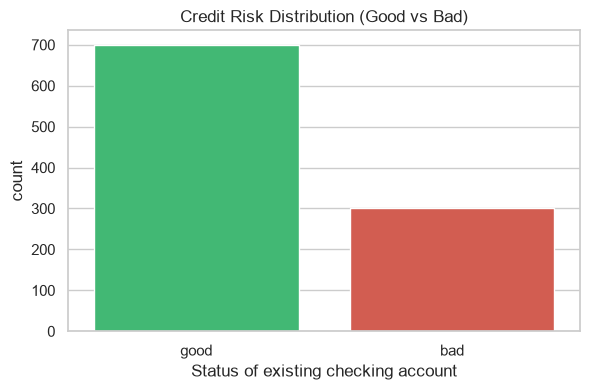

In [21]:
# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Status of existing checking account", palette=["#2ecc71", "#e74c3c"])
plt.title("Credit Risk Distribution (Good vs Bad)")
plt.show()

# Observations:
- The bar plot clearly illustrates the distribution of the target variable Status of existing checking account, where good risk applicants significantly outweigh bad risk applicants (700 vs. 300).   
- The target maintains a 70:30 split, reinforcing the presence of moderate class imbalance.

C:\Users\this pc\AppData\Local\Temp\ipykernel_12716\2726950555.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status of existing checking account', y="Credit amount", palette="Set2")


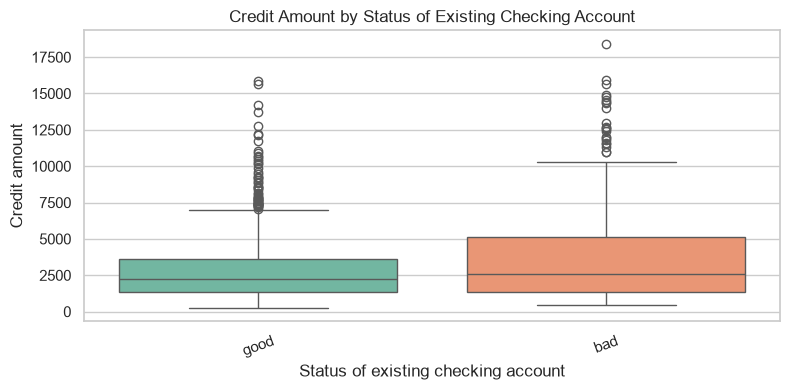

In [22]:
# Credit Amount Distribution across Checking Account Status
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Status of existing checking account', y="Credit amount", palette="Set2")
plt.title("Credit Amount by Status of Existing Checking Account")
plt.xticks(rotation=20)
plt.show()

# Observations:
- Applicants categorized as bad credit risk generally request larger loans, with a higher median credit amount compared to the good risk group.   
- The IQR for the bad class is substantially wider, spanning roughly from €1,500 to over €5,000, showing higher variability in loan sizes among high-risk applicants. In contrast, the good class maintains a tighter concentration between €1,200 and €3,500.   
- The good class exhibits numerous extreme values above the upper whisker (~€7,000), peaking around €16,000. The bad class features severe upper-tail outliers extending past 10,000 up to the dataset maximum near €18,424.

C:\Users\this pc\AppData\Local\Temp\ipykernel_12716\2802151863.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status of existing checking account', y="Duration in months", palette="Set2")


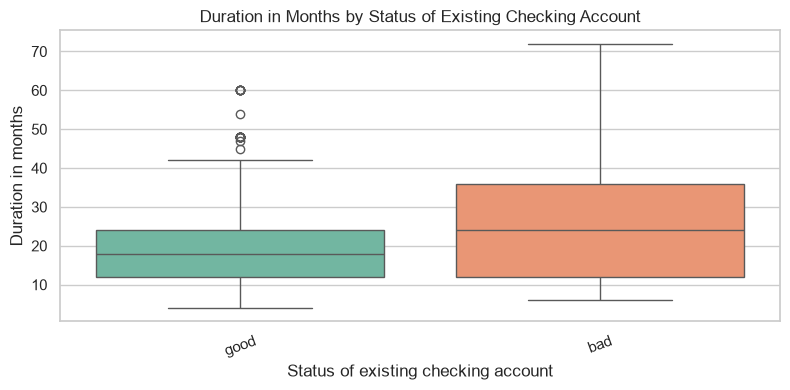

In [23]:
# Duration in Months vs. Checking Account Status
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Status of existing checking account', y="Duration in months", palette="Set2")
plt.title("Duration in Months by Status of Existing Checking Account")
plt.xticks(rotation=20)
plt.show()

# Observations:
- Applicants in the bad credit risk group have a noticeably higher median loan duration (around 24 months) compared to the good risk group (around 18 months).   
- The interquartile range (IQR) for high-risk accounts is significantly wider, extending from 12 to 36 months, with maximum values reaching up to 72 months.   
- The middle 50% of good credit risk applicants falls between 12 and 24 months, showing that shorter term lengths heavily correlate with successful credit performance.   
- The good class contains several long-term outliers ranging from 45 to 60 months.

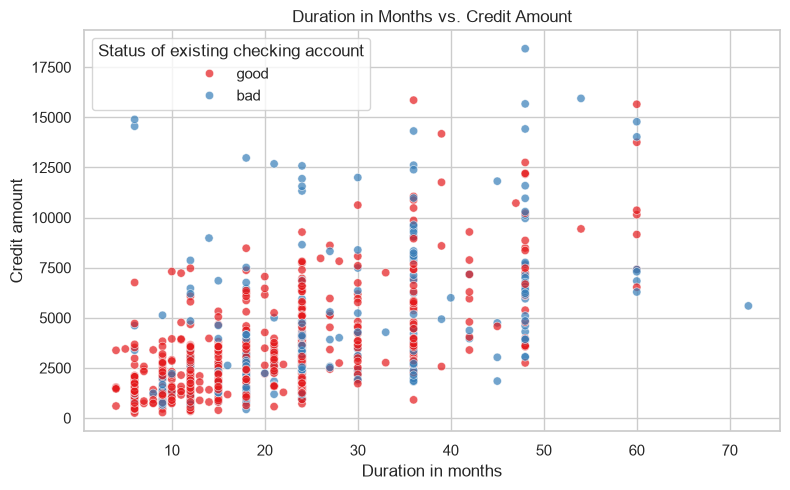

In [24]:
# Duration in Months vs. Credit Amount
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Duration in months",
    y="Credit amount",
    hue='Status of existing checking account',
    alpha=0.7,
    palette="Set1",
)
plt.title("Duration in Months vs. Credit Amount")
plt.show()

# Observations:
- There is a strong positive relationship between Duration in months and Credit amount as the loan duration extends, the requested credit amount increases significantly.   
- The bad credit risk observations (blue points) become noticeably denser at longer durations (>= 24 months) and higher credit amounts (> €5,000). The upper-right quadrant contains a higher proportion of bad risk accounts, illustrating the compound risk of large, long-term loans.
- The good risk observations (red points) dominate the bottom-left region, clustered under 24 months duration and €3,000 credit amount. 
- The scatter points form distinct vertical lines at standard loan terms (e.g., 6, 12, 18, 24, 36, 48, and 60 months). 

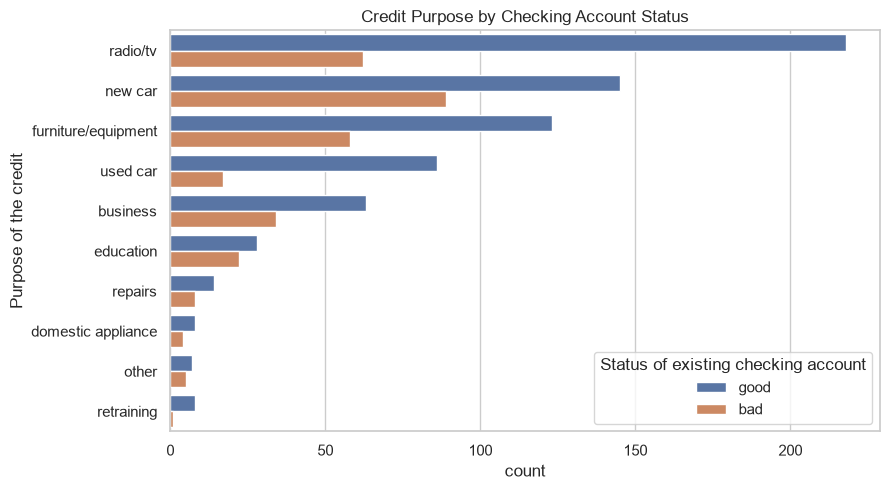

In [25]:
# Purpose of the Credit Breakdown
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df,
    y="Purpose of the credit",
    hue='Status of existing checking account',
    order=df["Purpose of the credit"].value_counts().index,
)
plt.title("Credit Purpose by Checking Account Status")
plt.show()

# Observations:
## Top Categories by Volume: 
- radio/tv, new car, and furniture/equipment represent the largest loan volumes overall.   

## Highest-Risk Credit Purposes:
- new car: Exhibits a high default ratio, with ~89 bad risk accounts relative to ~145 good risk accounts.   
- education: Shows a elevated default rate, where bad risk cases are nearly equal to good risk cases (~22 vs ~28).   

## Lowest-Risk Credit Purposes:
- used car: Displays a low default rate, with ~86 good risk accounts versus only ~17 bad risk accounts.   
- radio/tv: Maintains a favorable performance ratio, with over 215 good risk accounts compared to ~62 bad risk accounts.   

## Low-Frequency Categories: 
Categories like repairs, domestic appliance, other and retraining have minimal representation, contributing low variance to the dataset.   

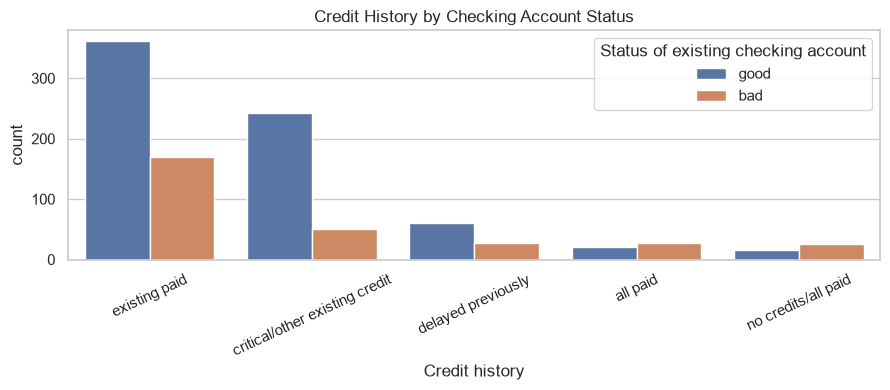

In [26]:
# Credit History Breakdown
plt.figure(figsize=(9, 4))
sns.countplot(
    data=df,
    x="Credit history",
    hue='Status of existing checking account',
    order=df["Credit history"].value_counts().index,
)
plt.title("Credit History by Checking Account Status")
plt.xticks(rotation=25)
plt.show()

# Observations:
- Dominant Category (existing paid): The majority of applicants fall into the existing paid category, accounting for over 350 good risk and approximately 170 bad risk instances.   
- Strongest Good Risk Ratio (critical/other existing credit): Applicants with a critical credit history or existing credits at other banks surprisingly exhibit a high proportion of good credit risk (~240 good vs. ~50 bad). This reflects the German Credit dataset anomaly where experienced borrowers with multiple loans are frequently lower-risk overall.   

## Higher Default Proportion in Special Categories:
- all paid: Shows a higher count of bad risk cases (~25) relative to good risk cases (~20).  
- no credits/all paid: Similarly indicates higher default occurrences (~25 bad risk vs. ~15 good risk). Applicants with no prior credit history in the system represent a higher uncertainty and risk profile.   

- delayed previously: Features around 60 good risk and 25 bad risk accounts, showing moderate volume with a performance ratio similar to existing paid. 

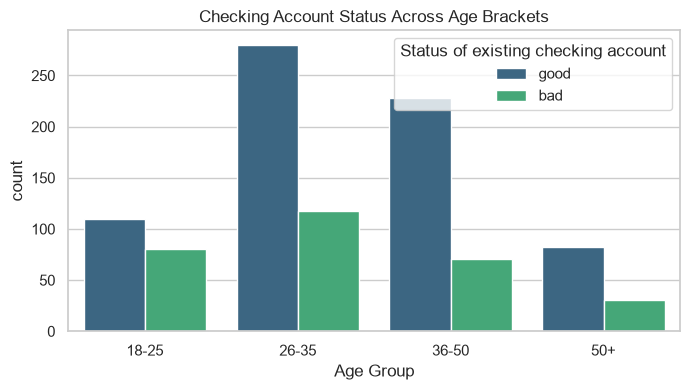

In [27]:
# Age Brackets Breakdown
df["Age_Group"] = pd.cut(
    df["Age in years"],
    bins=[18, 25, 35, 50, 80],
    labels=["18-25", "26-35", "36-50", "50+"],
)
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Age_Group", hue='Status of existing checking account', palette="viridis")
plt.title("Checking Account Status Across Age Brackets")
plt.xlabel("Age Group")
plt.show()

# Observations:
- Highest Default Proportion in Youngest Group (18-25): Applicants in the 18-25 age bracket display the highest default rate, with approximately 80 bad risk instances compared to 110 good risk instances (nearly a 42% default rate).

## Dominant Volume in Core Working Age Groups:
- 26-35: Represents the largest overall group, holding over 275 good risk and 115 bad risk accounts.
- 36-50: Shows stronger credit stability, with around 225 good risk cases versus only 70 bad risk cases.

## Lowest Risk in Older Demographics (50+): 
- Applicants aged 50+ exhibit the highest good-to-bad ratio (~80 good vs. ~30 bad), suggesting higher financial stability and lower credit default risk among older borrowers

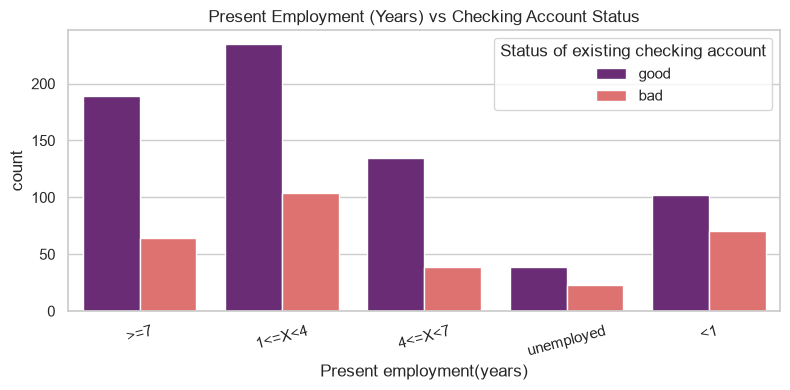

In [28]:
# Present Employment (Years) Breakdown
plt.figure(figsize=(8, 4))
sns.countplot(
    data=df, x="Present employment(years)", hue='Status of existing checking account', palette="magma"
)
plt.title("Present Employment (Years) vs Checking Account Status")
plt.xticks(rotation=15)
plt.show()

# Observations:
- There is an inverse Relationship Between Employment Tenure and Default Risk. Applicants with longer employment tenures demonstrate significantly lower default rates
- (>=7) years: Has a strong credit profile, featuring roughly 190 good risk cases versus 64 bad risk cases (around a 25% default rate).
- 4<=X<7 years: Also performs well, with approximately 135 good risk accounts to 38 bad risk accounts (around a 22% default rate).
- Elevated Risk for Short Employment Duration (<1 year). Applicants employed for less than a year show a significantly higher relative default rate, with around 70 bad risk instances against 102 good risk instances (over a 40% default rate).
- Largest Applicant Pool (1<=X<4 years): Represents the highest overall volume, containing over 235 good risk and 103 bad risk accounts.
- unemployed Category: Represents the lowest total count, showing about 38 good risk and 22 bad risk instances (~36% default rate).

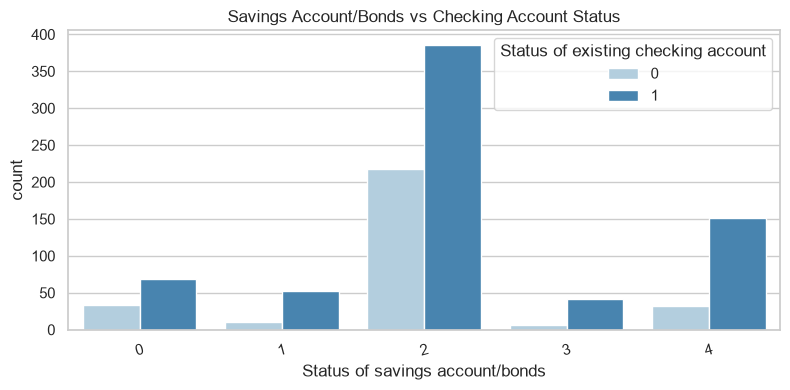

In [38]:
# Status of Savings Account/Bonds Breakdown
plt.figure(figsize=(8, 4))
sns.countplot(
    data=df,
    x="Status of savings account/bonds",
    hue= 'Status of existing checking account',
    palette="Blues",
)
plt.title("Savings Account/Bonds vs Checking Account Status")
plt.xticks(rotation=15)
plt.show()

# Observations:
## Dominant Category (<€100)
- The vast majority of applicants hold low savings balances (<€100), containing roughly 385 good risk and 215 bad risk cases (~35.8% default rate). 

##  Inverse Relationship Between Savings Volume and Default Risk:
- (>=€1000): Displays the lowest default rate, with approximately 40 good risk accounts against only 5 bad risk accounts (~11.1% default rate).
- €500<=X<€1000: Also exhibits low risk, featuring roughly 50 good risk and 10 bad risk instances (~16.7% default rate).   
- €100<=X<€500: Shows a moderate default profile, with around 68 good risk and 32 bad risk accounts (~32.0% default rate).   

## Strong Credit Performance in no known savings: 
- Surprisingly, applicants categorized under no known savings present a low default rate (~150 good risk vs. ~30 bad risk, or ~16.7% default rate). This typically aligns with established bank customers whose savings are held in untracked alternative assets or institutional relationships.

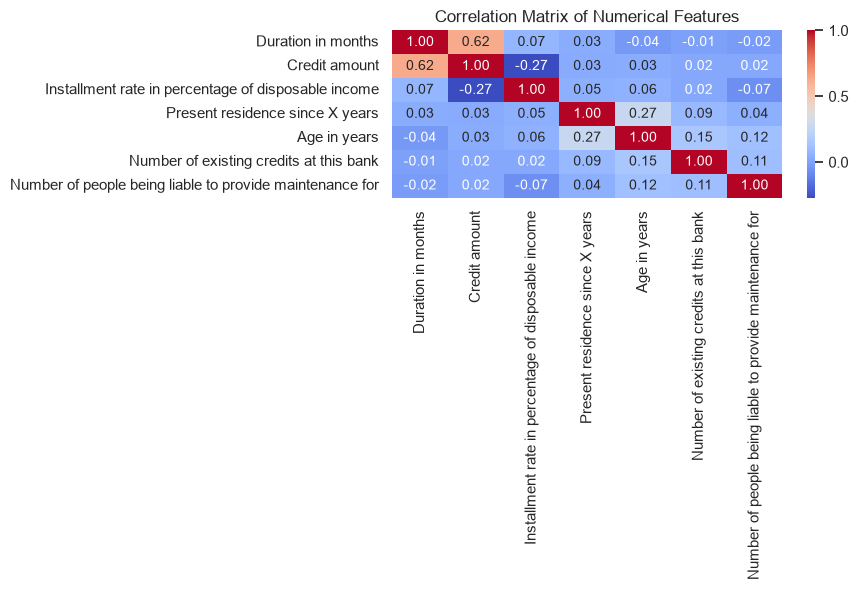

In [30]:
# Numerical Feature Correlation Matrix
plt.figure(figsize=(9, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop("id", errors="ignore")
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# Observations:
## Strongest Positive Correlation (r = 0.62): 
- A linear relationship exists between Duration in months and Credit amount. Longer term loans correspond directly to higher borrowing amounts.   

## Moderate Negative Correlation (r = -0.27): 
- Credit amount and Installment rate in percentage of disposable income show an inverse relationship. Larger loan sums are typically structured with lower relative installment percentages to keep payments manageable relative to income.   

## Mild Demographic Alignment (r = 0.27): 
- Age in years displays a mild correlation with Present residence since X years, indicating older applicants tend to stay at their current residence longer.   

## Overall Low Multicollinearity: 
- Most numerical features exhibit weak correlations (|r| < 0.15) with one another.

# Machine learning algorithms

In [31]:
# Preprocessing
# Drop 'id' column if present
if "id" in df.columns:
    df = df.drop(columns=["id"])

## Installing xgboost package

In [32]:
%pip install xgboost --break-system-packages

Note: you may need to restart the kernel to use updated packages.


## Machine learning packages

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier

In [34]:
target_col = "Status of existing checking account"

# Encode ALL object and categorical columns
label_encoders = {}
for col in df.select_dtypes(include=["object", "category"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Separate Features and Target
target_col = "Status of existing checking account"
X = df.drop(columns=[target_col])
y = df[target_col]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale Numerical Data (Works smoothly now)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

C:\Users\this pc\AppData\Local\Temp\ipykernel_12716\2659416716.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object", "category"]).columns:


In [35]:
# Model Dictionary
models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, class_weight="balanced"),
        X_train_scaled,
        X_test_scaled,
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42, class_weight="balanced"),
        X_train,
        X_test,
    ),
    "Random Forest": (
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
        X_train,
        X_test,
    ),
    "Extra Trees": (
        ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
        X_train,
        X_test,
    ),
    "XGBoost": (
        XGBClassifier(eval_metric="logloss", random_state=42),
        X_train,
        X_test,
    ),
}

In [36]:
# Model Training & Evaluation
results = []

for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    
    report = classification_report(y_test, preds, output_dict=True)
    
    results.append({
        "Model": name,
        "Accuracy": round(report["accuracy"], 4),
        "Macro Precision": round(report["macro avg"]["precision"], 4),
        "Macro Recall": round(report["macro avg"]["recall"], 4),
        "Macro F1-Score": round(report["macro avg"]["f1-score"], 4),
    })

# Output Summary Comparison Table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Macro Precision  Macro Recall  Macro F1-Score
Logistic Regression     0.640           0.6212        0.6429          0.6160
      Decision Tree     0.690           0.6243        0.6167          0.6197
      Random Forest     0.720           0.6667        0.6667          0.6667
        Extra Trees     0.745           0.7235        0.6083          0.6123
            XGBoost     0.710           0.6453        0.6262          0.6322


# Observations:
## Highest Accuracy & Precision (Extra Trees): 
- Extra Trees achieved the highest overall accuracy (0.7450) and macro precision (0.7235), but experienced a noticeable trade-off with a lower macro recall (0.6083).   

## Best Balanced Model (Random Forest): 
- Random Forest yielded the highest macro F1-score (0.6667), maintaining an ideal balance between macro precision (0.6667) and macro recall (0.6667) with strong overall accuracy (0.7200).   

## Competitive Gradient Boosting (XGBoost): 
- XGBoost performed reliably out-of-the-box (0.7100 accuracy, 0.6322 macro F1-score), trailing Random Forest slightly prior to hyperparameter optimization.   

## Underperformance of Linear Baseline (Logistic Regression): 
- Logistic Regression scored the lowest accuracy (0.6400), indicating that linear decision boundaries struggle to capture non-linear feature interactions without explicit polynomial feature engineering.   

## Decision Tree Variance: 
- A single Decision Tree achieved moderate accuracy (0.6900) and macro F1-score (0.6197), demonstrating higher variance compared to tree ensemble methods.

# Best model

In [37]:
import pickle

# Extract the Random Forest model and training data from models dictionary
rf_model, X_tr_rf, X_te_rf = models["Random Forest"]

# Ensure the Random Forest model is fitted on the training data
rf_model.fit(X_tr_rf, y_train)

# Save the trained Random Forest model to a .pkl file
pkl_filename = "random_forest_model.pkl"

with open(pkl_filename, "wb") as file:
    pickle.dump(rf_model, file)

print(f"Random Forest model saved successfully as '{pkl_filename}'")

Random Forest model saved successfully as 'random_forest_model.pkl'


# Conclusions:
## Model Performance and Selection:
- Random Forest emerged as the optimal model for production deployment, achieving a 0.7200 accuracy and the highest macro F1-score of 0.6667. It maintains a clean balance between precision (0.6667) and recall (0.6667), making it the most dependable model out-of-the-box. 
- Extra Trees delivered the highest overall accuracy (0.7450) and macro precision (0.7235), but sacrificed macro recall (0.6083), leading to a higher risk of failing to identify actual defaults. 
- Linear models (Logistic Regression) underperformed (0.6400 accuracy), confirming that credit risk evaluation relies heavily on non-linear relationships across features. 

## General insights:
- Financial Liquidity: Applicants with low savings balances (<€100) make up the bulk of defaults (~35.8%). Higher savings thresholds (>=€1000) strongly correlate with credit safety (~11.1% default rate). 
- Employment Tenure & Demographics: Younger applicants (18–25) and those with short employment histories (<1 year) present the highest default rates (~40.7% for short tenure). Conversely, longer employment duration (>=7 years) and older age groups demonstrate significantly lower default risks.   
- Borrowing Scale: Loan duration in months and credit amount show a strong positive correlation ($r = 0.62$), making long-term, large-amount credit requests higher exposure risks.